# Natural Language Processing com Deep Learning

O propósito deste Notebook é utilizar conhecimentos de Deep Learning para classificar frases sintéticas (geradas por um LLM) em uma dimensão binária que determine um sentimento, positivo ou negativo. A tarefa de classificação descrita é conhecida por "análise de sentimentos".

O resultado do modelo com rede neural será comparado com os dados sintéticos através da comparação entre o target esperado e o executado pelo modelo.

## Metodologia

### Preparação dos dados

O carregamento dos dados será feito através do Kaggle Hub para continuar o uso do dataset do trabalho anterior. O dataset utilizado é proveniente do projeto **Opinando**, o *UTLCorpus*. Este dataset possui mais de 2 milhões de resenhas de filmes coletadas do Filmow, uma popular rede social de filmes, e foi tratado especificamente como UTLC-Movies neste contexto, com todas as avaliações que possuíam classificação 0 removidas para garantir a qualidade dos dados.

Os dados do dataset serão preparados de forma simples, será selecionado do conjunto de 10.000 amostras as colunas "review_text" e "polarity". Sendo que, para balancear as amostras, metade dos dados do conjunto será de resenhas positivas (`polarity == 1`) e a outra metade de resenhas negativas (`polarity == 0`).

Do conjunto total dos dados, 9.000 amostras serão utilizadas para treinamento (4.500 resenhas positivas e 4.500 resenhas negativas) e apenas 1000 serão utilizadas para teste (500 resenhas positivas e 500 resenhas negativas).

In [1]:
"""
Carregando o dataset de análise de sentimentos em português do Kaggle.
O dataset contém resenhas de filmes, com a respectiva polaridade (1 para positivo e 0 para negativo) e a classificação (de 1 a 5 estrelas).
Para acelerar o treinamento do modelo, diminui o tamanho do dataset para 10.000 amostras, garantindo a mesma proporção de classes positivas e negativas.
"""
%pip install ipywidgets kagglehub pandas numpy -q
import kagglehub
import pandas as pd
from kagglehub import KaggleDatasetAdapter


dataset_handle = "fredericods/ptbr-sentiment-analysis-datasets"
dataset_file = "utlc_movies.csv"

df: pd.DataFrame = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    dataset_handle,
    dataset_file,
)
df = df[["review_text", "polarity"]]

Note: you may need to restart the kernel to use updated packages.


In [2]:
print(df.info(), df.head())

<class 'pandas.DataFrame'>
RangeIndex: 1487449 entries, 0 to 1487448
Data columns (total 2 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   review_text  1487449 non-null  str    
 1   polarity     1189542 non-null  float64
dtypes: float64(1), str(1)
memory usage: 22.7 MB
None                                          review_text  polarity
0                         Um dos melhores desenhos!!       1.0
1  O filme é realmente diferente e bem lento mas ...       1.0
2     Hilário em alguns momentos, e muito bem feito.       1.0
3                         choro toda vez que vejo :(       1.0
4                                           Niiiice!       1.0


In [3]:
import pandas as pd

N_SAMPLES = 10_000

TRAIN_SIZE = 9_000
TEST_SIZE = N_SAMPLES - TRAIN_SIZE

positive_samples = df[df["polarity"] == 1].sample(
    n=(N_SAMPLES // 2),
    random_state=42,
)
negative_samples = df[df["polarity"] == 0].sample(
    n=(N_SAMPLES // 2),
    random_state=42,
)

train_df = (
    pd.concat(
        [positive_samples[: TRAIN_SIZE // 2], negative_samples[: TRAIN_SIZE // 2]],
    )
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)
test_df = (
    pd.concat(
        [positive_samples[TRAIN_SIZE // 2 :], negative_samples[TRAIN_SIZE // 2 :]],
    )
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

X_train, y_train, X_test, y_test = (
    train_df["review_text"],
    train_df["polarity"],
    test_df["review_text"],
    test_df["polarity"],
)

print("Tamanho do conjunto de treinamento:", len(X_train))
print("Tamanho do conjunto de teste:", len(X_test))

Tamanho do conjunto de treinamento: 9000
Tamanho do conjunto de teste: 1000


### Embedding Pre-Trained Model

Como o objetivo deste Python Notebook é realizar o treinamento de um modelo para análise de sentimentos utilizando aprendizado profundo, o modelo de embedding será carregado a partir de um modelo treinado previamente e disponibilizado no catalogo da *Hugging Face*.

Iremos utilizar o modelo da família *SBERT* conhecido como *paraphrase-multilingual-MiniLM-L12-v2* que possui suporte para o idioma Português e é treinado para a tarefa de embedding. O carregamento do modelo será feito utilizando a biblioteca `sentence_transformers`.

In [4]:
%pip install sentence-transformers -q
import torch
from sentence_transformers import SentenceTransformer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
embedding_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', backend='torch', device=device)

Note: you may need to restart the kernel to use updated packages.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Treinamento do modelo



In [5]:
import torch
from torch import nn
from torch.accelerator import current_accelerator, is_available


# Definindo um modelo simples de Multilayer Perceptron (MLP) para classificação de sentimentos
class MLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 5),
        )

    def forward(self, x) -> torch.Tensor:
        return self.net(x)


device = current_accelerator().type if is_available() else "cpu"

# Criando o modelo utilizando a dimensão de embedding do modelo pré-treinado como entrada
classifier_model = MLP(input_dim=embedding_model.get_sentence_embedding_dimension()).to(
    device
)

# Definindo a função de perda e o otimizador para treinamento do modelo de classificação
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier_model.parameters())

In [6]:
import torch
from torch import nn
from torch.optim import Optimizer
from torch.utils.data import DataLoader

# type aliases
Loss = float
Accuracy = float


def train(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: Optimizer,
    criterion: nn.Module,
) -> Loss:
    model.train()
    total_loss = 0
    for batch in dataloader:
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(dataloader)


def evaluate(
    model: nn.Module, dataloader: DataLoader, criterion: nn.Module
) -> tuple[Loss, Accuracy]:
    model.eval()
    total_loss = 0
    correct = 0
    with torch.no_grad():
        for batch in dataloader:
            inputs, labels = batch
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
    accuracy = correct / len(dataloader.dataset)
    return total_loss / len(dataloader), accuracy

In [18]:
# @title Treinamento do modelo de classificação de sentimentos
from torch.utils.data import TensorDataset, DataLoader

# Convertendo os textos de treinamento e teste em embeddings utilizando o modelo pré-treinado
train_dataset = TensorDataset(
    embedding_model.encode(X_train.tolist(), convert_to_tensor=True),
    torch.tensor(y_train.values, dtype=torch.long),
)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(
    embedding_model.encode(X_test.tolist(), convert_to_tensor=True),
    torch.tensor(y_test.values, dtype=torch.long),
)
test_dataloader = DataLoader(test_dataset, batch_size=32)

# Treinando o modelo por 5 épocas
EPOCHS = 5
for epoch in range(EPOCHS):
    train_loss = train(classifier_model, train_dataloader, optimizer, criterion)
    test_loss, test_accuracy = evaluate(classifier_model, test_dataloader, criterion)
    print(
        f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f} - Test Loss: {test_loss:.4f} - Test Accuracy: {test_accuracy:.4f}"
    )

Epoch 1/10 - Train Loss: 0.3470 - Test Loss: 0.5059 - Test Accuracy: 0.7720
Epoch 2/10 - Train Loss: 0.3330 - Test Loss: 0.5258 - Test Accuracy: 0.7680
Epoch 3/10 - Train Loss: 0.3185 - Test Loss: 0.5550 - Test Accuracy: 0.7640
Epoch 4/10 - Train Loss: 0.3044 - Test Loss: 0.5539 - Test Accuracy: 0.7620
Epoch 5/10 - Train Loss: 0.2931 - Test Loss: 0.5740 - Test Accuracy: 0.7550
Epoch 6/10 - Train Loss: 0.2767 - Test Loss: 0.5821 - Test Accuracy: 0.7460
Epoch 7/10 - Train Loss: 0.2644 - Test Loss: 0.6117 - Test Accuracy: 0.7610
Epoch 8/10 - Train Loss: 0.2474 - Test Loss: 0.6263 - Test Accuracy: 0.7700
Epoch 9/10 - Train Loss: 0.2359 - Test Loss: 0.6697 - Test Accuracy: 0.7510
Epoch 10/10 - Train Loss: 0.2234 - Test Loss: 0.7081 - Test Accuracy: 0.7540


In [ ]:
%pip install seaborn matplotlib -q
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from torch import nn
from sklearn.metrics import confusion_matrix


def plot_confusion_matrix(y_true: list, y_pred: list, title: str) -> None:
    cv = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cv, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

def predict(model: nn.Module, texts: list) -> list:
    model.eval()
    with torch.no_grad():
        embeddings = embedding_model.encode(texts, convert_to_tensor=True).to(device)
        outputs = model(embeddings)
        _, predicted = torch.max(outputs, 1)
    return predicted.cpu().numpy()

Note: you may need to restart the kernel to use updated packages.


Relatório de Classificação - Test Data
              precision    recall  f1-score   support

         0.0       0.74      0.79      0.76       500
         1.0       0.77      0.72      0.74       500

    accuracy                           0.75      1000
   macro avg       0.76      0.75      0.75      1000
weighted avg       0.76      0.75      0.75      1000



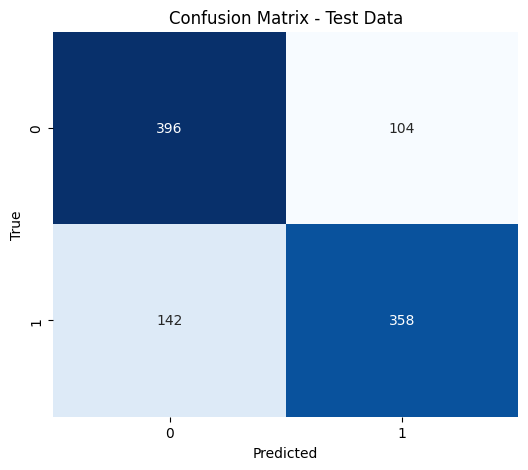

              precision    recall  f1-score   support

           0       0.94      0.98      0.96        50
           1       0.98      0.94      0.96        50

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



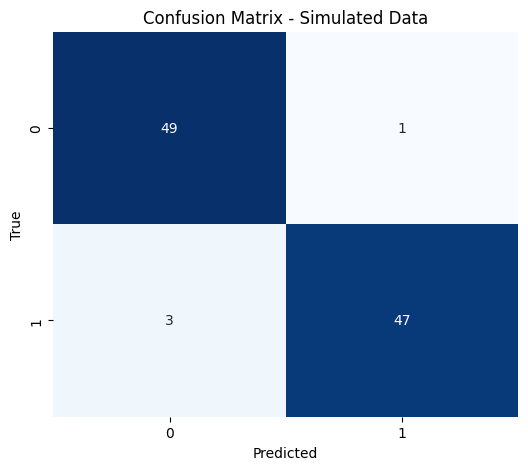

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

# Avaliação do modelo em dados de teste
y_true = y_test.values
y_pred = predict(classifier_model, X_test.tolist())

print("Relatório de Classificação - Test Data")
print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred, "Confusion Matrix - Test Data")

# Avaliação do modelo em dados simulados
simulated_texts = pd.read_csv("simulated_reviews.csv")
y_true = simulated_texts["polarity"].values
y_pred = predict(classifier_model, simulated_texts["review_text"].tolist())

print("Relatório de Classificação - Simulated Data")
print(classification_report(y_true, y_pred))
plot_confusion_matrix(y_true, y_pred, "Confusion Matrix - Simulated Data")